# Eksperiment menggunakan google/mt5-small - Abstractive SUmmary

- Menggunakan jumlah data train = 5000, dev =1071 , dan test = 1071
- Menggunakan learning_rate=3e-5,
- Epoch = 7
- num_beam = 5
- max_length=128
- min_length=50

- {'test_loss': 2.3606443405151367, 'test_rouge1': 33.894, 'test_rouge2': 16.4983, 'test_rougeL': 26.871, 'test_runtime': 808.491, 'test_samples_per_second': 1.325, 'test_steps_per_second': 0.663}

In [1]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cek GPU
import torch
print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Menggunakan perangkat: {device}")

True
Menggunakan perangkat: cuda


###***Ambil Dataset dari Kaggle***

In [3]:
# Upload ke Google Colab

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nalaprogroup","key":"6e69ae1b1b69e1a4d23d6edf0680d84f"}'}

In [4]:
# Set Permission
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
#Install Kaggle CLI
!pip install kaggle

In [6]:
# Download Dataset
# url : https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2-v2

!kaggle datasets download -d nalaprogroup/clean-data-project2-v2

Dataset URL: https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2-v2
License(s): CC0-1.0
100% 3.82M/3.82M [00:01<00:00, 2.08MB/s]



In [7]:
# Extract File
!unzip clean-data-project2-v2.zip

Archive:  clean-data-project2-v2.zip
  inflating: dev_text_clean.json     
  inflating: test_text_clean.json    
  inflating: train_text_clean.json   


In [8]:
# memindahkan file ke sample_data/liputan6
!mkdir -p /content/sample_data/liputan6

!mv dev_text_clean.json /content/sample_data/liputan6
!mv test_text_clean.json /content/sample_data/liputan6
!mv train_text_clean.json /content/sample_data/liputan6

###***Dataset***

In [9]:
# Load 1 sample dulu
import json

with open('/content/sample_data/liputan6/train_text_clean.json') as f:
    data_train = json.load(f)

print("Jml train_text_clean :",len(data_train))

with open('/content/sample_data/liputan6/dev_text_clean.json') as g:
    data_dev = json.load(g)

print("Jml dev_text_clean :",len(data_dev))


with open('/content/sample_data/liputan6/test_text_clean.json') as h:
    data_test = json.load(h)

print("Jml test_text_clean :",len(data_test))


sample = data_train[0]

print("ID:\n", sample['id'])
print("ARTICLE:\n", sample['clean_article'])
print("\nClean SUMMARY:\n", sample['clean_summary'])
print("\nSUMMARY:\n", sample['extractive_summary'])

Jml train_text_clean : 5000
Jml dev_text_clean : 1071
Jml test_text_clean : 1071
ID:
 198679
ARTICLE:
 Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musim tanam para petani harus mengeluarkan b

In [10]:
# Validasi otomatis  - Abstractive Summary/Clean_Summary

empty_summary_idx = []

for i, sample in enumerate(data_train):
    summary = sample.get('clean_summary', None)

    if summary is None or summary.strip() == "":
        empty_summary_idx.append(i)

print("Jumlah summary kosong:", len(empty_summary_idx))
print("Contoh index:", empty_summary_idx[:10])

Jumlah summary kosong: 0
Contoh index: []


In [11]:
# Cek Clean_Summary yang kosong
for i in empty_summary_idx[:5]:
    print(f"\n=== DATA INDEX {i} ===")
    print("ARTICLE:\n", data_train[i]['clean_article'])
    print("\nSUMMARY:\n", data_train[i]['clean_summary'])

In [12]:
# Split jadi kalimat

import re

def split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return sentences

sentences = split_sentences(sample['clean_article'])

for i, s in enumerate(sentences):
    print(i, s)

0 Pada hari Minggu, 18 Mei 2008, pelatih Timnas Prancis, Raymond Domenech secara resmi mengumumkan skuad provisionalnya berjumlah 30 pemain yang dipersiapkan mengarungi turnamen putaran final Euro 2008, 7-29 Juni mendatang di Austria-Swiss.
1 Masalahnya, tidak sedikit kalangan yang memertanyakan kebijakan Domenech yang tidak memanggil striker andalan Juventus, David Trezeguet.
2 Padahal, di sepanjang musim ini produktivitas Trezeguet terbilang subur: mencetak 20 gol, atau hanya terpaut satu gol dari pencapaian tandemnya, Alessandro Del Piero.
3 Untuk mengisi pos yang ditingggalkan Trezeguet, Domenech malah memanggil striker muda St Ettiene, Bafetimbi Gomis, yang baru berusia 22 tahun.
4 Salah satu dari kalangan banyak yang meragukan keputusan Domenceh adalah bos Trezeguet di Turin, pelatih La Vecchia Signora, Claudio Ranieri.
5 “ Saya sangat heran dan tak habis pikir dengan keputusan itu.
6 ia pemain yang fantastis.
7 Di kotak 16 meter sikapnya seperti predator dan mampu membuktikan di

In [13]:
# Validasi otomatis  - Extractive Summary
def validate_data(sample):
    sentences = split_sentences(sample['clean_article'])
    summary = sample['extractive_summary']

    if isinstance(summary[0], int):
        # index-based
        for idx in summary:
            if idx >= len(sentences):
                return False
        return True
    else:
        # text-based
        for s in summary:
            if not any(s in sent for sent in sentences):
                return False
        return True

valid_count = 0

for i in range(5000):  # cek 100 sample dulu
    if validate_data(data_train[i]):
        valid_count += 1

print("Valid:", valid_count, "/ 5000")

Valid: 4961 / 5000


In [14]:
# Ambil index data tidak valid - Extractive Summary
invalid_indices = []

for i, sample in enumerate(data_train):
    if not validate_data(sample):
        invalid_indices.append(i)

print("Jumlah tidak valid:", len(invalid_indices))
print("Contoh index:", invalid_indices[:10])

Jumlah tidak valid: 39
Contoh index: [100, 149, 559, 881, 982, 1016, 1036, 1081, 1224, 1316]


# google/mt5-small Start

In [15]:
!pip install transformers[torch] datasets evaluate rouge_score accelerate sentencepiece -U

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 119.0 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=498e0eab2bd5862da27995e006e980d1b9826f673ed91d015eb7ef3931c509e3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: 

In [16]:
# Import Library

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

from datasets import Dataset
import evaluate
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Convert ke HuggingFace Dataset
# from datasets import Dataset

train_dataset = Dataset.from_list(data_train)
dev_dataset = Dataset.from_list(data_dev)
test_dataset = Dataset.from_list(data_test)

In [18]:
# pembatasan dataset untuk testing script
#train_dataset = train_dataset.select(range(10))
#dev_dataset = dev_dataset.select(range(10))
#test_dataset = test_dataset.select(range(10))

In [19]:
# cek dataset

print(train_dataset)

for i in range(3):
    print(train_dataset[i])
    print("="*50)

#print(len(train_dataset[0]["clean_article"]))
#print(len(train_dataset[0]["clean_summary"]))

print("="*50)

print(train_dataset.column_names)

Dataset({
    features: ['id', 'clean_article', 'clean_summary', 'extractive_summary'],
    num_rows: 5000
})
{'id': 198679, 'clean_article': 'Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musi

In [20]:
# menyesuaikan kolom untuk dataset

# mengubah nama kolom
train_dataset = train_dataset.rename_columns({
    "clean_article": "article",
    "clean_summary": "summary"
})

dev_dataset = dev_dataset.rename_columns({
    "clean_article": "article",
    "clean_summary": "summary"
})

test_dataset = test_dataset.rename_columns({
    "clean_article": "article",
    "clean_summary": "summary"
})

# menghapus kolom tidak digunakan
train_dataset = train_dataset.remove_columns(["id", "extractive_summary"])
dev_dataset = dev_dataset.remove_columns(["id", "extractive_summary"])
test_dataset = test_dataset.remove_columns(["id", "extractive_summary"])

In [21]:
print(train_dataset[0])

{'article': 'Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musim tanam para petani harus mengeluarkan biaya hingga jutaan rupiah. Bahkan tidak jarang berhutang kepada tengkulak hanya untuk memb

In [22]:
import numpy as np

article_lens = [len(x["article"]) for x in train_dataset]
summary_lens = [len(x["summary"]) for x in train_dataset]

print("Avg article:", np.mean(article_lens))
print("Avg summary:", np.mean(summary_lens))

Avg article: 1340.9384
Avg summary: 193.072


In [23]:
# Load model google/mt5-small

model_name = "google/mt5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [24]:
# KONFIGURASI MODEL (Ubah perilaku model)

from transformers import GenerationConfig

# 1. Definisikan konfigurasi generasi yang baru
generation_config = GenerationConfig(
    max_length=128,
    min_length=50,
    num_beams=5,
    early_stopping=True,
    length_penalty=2.0,
    no_repeat_ngram_size=3,
    decoder_start_token_id=model.config.decoder_start_token_id,
    eos_token_id=model.config.eos_token_id,
    pad_token_id=model.config.pad_token_id,
)

# 2. Masukkan konfigurasi ini ke dalam model
model.generation_config = generation_config

In [25]:
# PREPROCESS

def preprocess_function(examples):
    inputs = ["summarize: " + doc for doc in examples["article"]]

    model_inputs = tokenizer(
        inputs,
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        examples["summary"],
        max_length=150,
        truncation=True,
        padding="max_length"
    )

    # masking padding token
    labels["input_ids"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [26]:
# Tokenization

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_dev   = dev_dataset.map(preprocess_function, batched=True)
tokenized_test  = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1071 [00:00<?, ? examples/s]

Map:   0%|          | 0/1071 [00:00<?, ? examples/s]

In [27]:
# tokenized_train[0]

In [28]:
# metric

rouge = evaluate.load("rouge")

import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Pastikan predictions adalah array numpy
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Kadang predictions berisi ID yang di luar range karena proses generation
    # Kita clip atau bersihkan jika perlu, tapi biasanya masalah ada di labels

    # PERBAIKAN UTAMA: Pastikan labels benar-benar bersih dari -100
    # Ganti semua -100 dengan pad_token_id (biasanya 0 pada mT5)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode dengan pengamanan tambahan
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Lanjutkan ke perhitungan ROUGE...
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    return {
        "rouge1": round(result["rouge1"] * 100, 4),
        "rouge2": round(result["rouge2"] * 100, 4),
        "rougeL": round(result["rougeL"] * 100, 4)
    }

In [29]:
# TRAINING ARGUMENTS
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",        # Sudah diperbaiki dari sebelumnya
    save_strategy="epoch",
    learning_rate=3e-5,
#    learning_rate=1e-5,
    report_to="none",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=7,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    save_total_limit=2,
    fp16=False,
    bf16=False,                # Pastikan ini juga False
    predict_with_generate=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [30]:
# Data Collator

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    label_pad_token_id=-100, # Memastikan padding label ditandai -100
    pad_to_multiple_of=None
#    pad_to_multiple_of=8 if training_args.fp16 else None # Optimasi untuk FP16
)

In [31]:
# TRAINER

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    data_collator=data_collator,
    processing_class=tokenizer, # <-- Coba ganti 'tokenizer' menjadi 'processing_class'
    compute_metrics=compute_metrics
)

In [32]:
# TRAINING
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,2.726902,2.621279,32.079000,15.418600,25.356800
2,2.360718,2.462853,33.777900,16.507500,26.554500
3,2.200523,2.449810,33.304400,16.137600,26.254400
4,2.159816,2.388782,33.519400,16.259000,26.617500
5,2.096022,2.370701,33.930600,16.625500,27.009300
6,2.093606,2.385611,33.801500,16.399500,26.808900
7,2.071091,2.360644,33.894000,16.498300,26.871000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=17500, training_loss=2.494681397356306, metrics={'train_runtime': 11500.7443, 'train_samples_per_second': 3.043, 'train_steps_per_second': 1.522, 'total_flos': 1.85062391808e+16, 'train_loss': 2.494681397356306, 'epoch': 7.0})

In [33]:
results_predict = trainer.predict(tokenized_dev)
print(results_predict.metrics)

{'test_loss': 2.3606443405151367, 'test_rouge1': 33.894, 'test_rouge2': 16.4983, 'test_rougeL': 26.871, 'test_runtime': 808.491, 'test_samples_per_second': 1.325, 'test_steps_per_second': 0.663}


In [34]:
# Simpan model dan tokenizer ke satu folder khusus
model_path = "./model_final_summarization"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model_final_summarization/tokenizer_config.json',
 './model_final_summarization/tokenizer.json')

In [35]:
!zip -r model_summarization.zip ./model_final_summarization

  adding: model_final_summarization/ (stored 0%)
  adding: model_final_summarization/model.safetensors (deflated 24%)
  adding: model_final_summarization/training_args.bin (deflated 53%)
  adding: model_final_summarization/tokenizer.json (deflated 76%)
  adding: model_final_summarization/config.json (deflated 49%)
  adding: model_final_summarization/tokenizer_config.json (deflated 85%)
  adding: model_final_summarization/generation_config.json (deflated 58%)


In [36]:
# Tentukan path tujuan
dest_path = "/content/drive/MyDrive/Colab\ Notebooks/Model/TextSummarization_mt5_small_v1"

# Buat folder tujuan jika belum ada
!mkdir -p {dest_path}

# Salin file zip ke folder tersebut
!cp model_summarization.zip {dest_path}

# Verifikasi apakah file sudah tersalin
!ls {dest_path}

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_5026/2217537362.py:2: SyntaxWarning: invalid escape sequence '\ '
  dest_path = "/content/drive/MyDrive/Colab\ Notebooks/Model/TextSummarization_mt5_small_v1"


model_summarization.zip


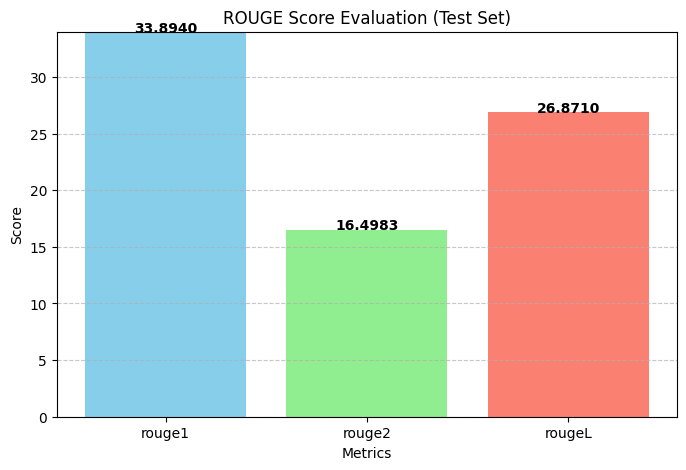

In [37]:
# VISUALISASI HASIL results_predict

# Ambil metrik dari hasil predict (biasanya berawalan 'test_')
# Kita gunakan .get() agar tidak error jika key tidak ditemukan
metrics_names = ["rouge1", "rouge2", "rougeL"]
scores = [results_predict.metrics.get(f"test_{m}", 0) for m in metrics_names]

# Jika kamu ingin menampilkan dalam skala 0-100 (persen)
# scores = [s * 100 for s in scores]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, scores, color=['skyblue', 'lightgreen', 'salmon'])

# Tambahkan angka di atas bar agar lebih jelas
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.title("ROUGE Score Evaluation (Test Set)")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores) + 0.1 if scores else 1) # Beri ruang di atas bar
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [38]:
import numpy as np

# Ambil hasil prediksi teks
predictions = results_predict.predictions
labels = results_predict.label_ids

# Decode menjadi teks
decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

# Lihat 3 contoh pertama
for i in range(100, 106):
    print(f"Prediksi: {decoded_preds[i]}")
    print(f"Asli    : {decoded_labels[i]}")
    print("-" * 30)

Prediksi: Sebagian petani tembakau di Pulau Lombok, Nusatenggara Barat, lebih memilih menumpuk hasil panen daripada menjual ke pasar. Mereka mengaku bukan saja tak memperoleh keuntungan tapi juga tak dapat menutupi modal kerja.
Asli    : Karena harga tembakau di NTB menukik tajam, para petani lebih memilih menumpuk atau membakar hasil panennya. Keadaan itu disebabkan oleh biaya produksi yang tinggi.
------------------------------
Prediksi: Ratusan karyawan PT Sumiati sudah tak tahan menderita. Selama ini, upah yang mereka terima di bawah standar kebutuhan hidup minimum di Pulau Dewata, tak pernah diselesaikan secara bijaksana.
Asli    : Sebanyak 1. 600 pegawai PT Sumiati yang terletak di kawasan pariwisata Kuta Bali, berdemonstrasi menuntut kenaikan upah dan pembentukan Serikat Pekerja Seluruh Indonesia.
------------------------------
Prediksi: Ratusan orang yang mendaftar hendak mengambil mobil rongsokan miliknya yang berada di areal parkir P2 di gedung Bursa Efek Jakarta. Diperkiraka

In [39]:
# INFERENCE

def summarize(text):
    # Tentukan device (cek apakah model ada di cuda atau cpu)
    device = next(model.parameters()).device

    inputs = tokenizer(
        "summarize: " + text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device) # <--- TAMBAHKAN INI: Pindahkan semua tensor input ke GPU

    outputs = model.generate(
        inputs["input_ids"],
        max_length=150,
        num_beams=4,
        early_stopping=True
    )

    # Decode hasil
    decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # MEMBERSIHKAN TAG <extra_id_0>
    clean_output = decoded_output.replace("<extra_id_0>", "").strip()

    return clean_output

# contoh
print(summarize(train_dataset[1000]["article"]))

Kepolisian Daerah Riau menghentikan penyidikan kasus pembalakan liar terhadap 13 perusahaan kayu dibela Polri. Alasannya, tak cukup bukti atas pelanggaran yang dituduhkan. Polri mempersilahkan siapa saja yang tak bisa menerima keputusan itu untuk mempra-peradilkan Polda Riau.


In [40]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.5 MB/s eta 0:00:00


In [41]:
import evaluate
import numpy as np
import pandas as pd

def run_full_evaluation(predictions, references):
    print("Wait... Sedang menghitung metrik (ini mungkin memakan waktu beberapa menit)...")

    # 1. Load Metrics
    rouge_metric = evaluate.load("rouge")
    bertscore_metric = evaluate.load("bertscore")

    # 2. Hitung ROUGE
    # rouge_types bisa disesuaikan, standar: rouge1, rouge2, rougeL
    rouge_results = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True
    )

    # 3. Hitung BERTScore
    # Menggunakan model multilingual yang mendukung Bahasa Indonesia (lang="id")
    # Di Colab Pro, proses ini akan otomatis menggunakan GPU jika tersedia
    bert_results = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="id"
    )

    # 4. Rangkum Hasil ke dalam DataFrame agar rapi
    summary_dict = {
        "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore Precision", "BERTScore Recall", "BERTScore F1"],
        "Score": [
            rouge_results["rouge1"],
            rouge_results["rouge2"],
            rouge_results["rougeL"],
            np.mean(bert_results["precision"]),
            np.mean(bert_results["recall"]),
            np.mean(bert_results["f1"])
        ]
    }

    df_results = pd.DataFrame(summary_dict)

    # Menampilkan tabel hasil
    print("\n" + "="*30)
    print("HASIL EVALUASI MODEL")
    print("="*30)
    print(df_results.to_string(index=False))
    print("="*30)

    return df_results

# --- EKSEKUSI ---
# Menggunakan variabel decoded_preds dan decoded_labels yang sudah Anda miliki
evaluation_report = run_full_evaluation(decoded_preds, decoded_labels)

# Tambahan: Melihat perbandingan data spesifik (misal indeks 100-105) untuk kualitatif
print("\nSampel Perbandingan (Indeks 100-105):")
for i in range(100, 106):
    print(f"\n[Data {i}]")
    # Membersihkan tag <extra_id_0> jika masih ada
    p = decoded_preds[i].replace("<extra_id_0>", "").strip()
    l = decoded_labels[i].strip()
    print(f"Prediksi : {p}")
    print(f"Asli     : {l}")

Wait... Sedang menghitung metrik (ini mungkin memakan waktu beberapa menit)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



HASIL EVALUASI MODEL
             Metric    Score
            ROUGE-1 0.339502
            ROUGE-2 0.164803
            ROUGE-L 0.268904
BERTScore Precision 0.736145
   BERTScore Recall 0.772846
       BERTScore F1 0.753808

Sampel Perbandingan (Indeks 100-105):

[Data 100]
Prediksi : Sebagian petani tembakau di Pulau Lombok, Nusatenggara Barat, lebih memilih menumpuk hasil panen daripada menjual ke pasar. Mereka mengaku bukan saja tak memperoleh keuntungan tapi juga tak dapat menutupi modal kerja.
Asli     : Karena harga tembakau di NTB menukik tajam, para petani lebih memilih menumpuk atau membakar hasil panennya. Keadaan itu disebabkan oleh biaya produksi yang tinggi.

[Data 101]
Prediksi : Ratusan karyawan PT Sumiati sudah tak tahan menderita. Selama ini, upah yang mereka terima di bawah standar kebutuhan hidup minimum di Pulau Dewata, tak pernah diselesaikan secara bijaksana.
Asli     : Sebanyak 1. 600 pegawai PT Sumiati yang terletak di kawasan pariwisata Kuta Bali, berdemonstra

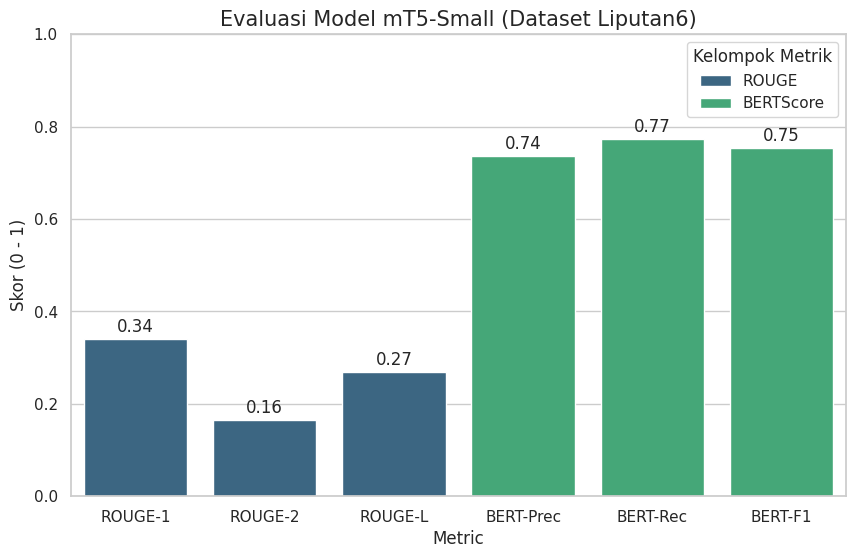

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data dari hasil evaluasi Anda
data = {
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERT-Prec', 'BERT-Rec', 'BERT-F1'],
    'Score': [0.339502, 0.164803, 0.268904, 0.736145, 0.772846, 0.753808],
    'Category': ['ROUGE', 'ROUGE', 'ROUGE', 'BERTScore', 'BERTScore', 'BERTScore']
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Membuat Bar Plot
ax = sns.barplot(x='Metric', y='Score', hue='Category', data=df, palette='viridis')

# Menambahkan angka di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.title('Evaluasi Model mT5-Small (Dataset Liputan6)', fontsize=15)
plt.ylim(0, 1.0) # Skala 0 sampai 1
plt.ylabel('Skor (0 - 1)')
plt.legend(title='Kelompok Metrik')
plt.show()

# Analisa Hasil Scoring

***1. Analisis Skor ROUGE (Kecocokan Kata)***

Skor ROUGE Anda berada di angka 0.25 - 0.29 (ROUGE-1/L).

Maknanya: Model Anda berhasil menangkap sekitar 25-29% kata kunci atau frasa yang sama persis dengan ringkasan asli Liputan6.

Konteks: Untuk model berukuran "Small", angka ini sebenarnya sudah cukup oke sebagai awal, tetapi masih ada ruang besar untuk perbaikan. Biasanya, model yang sudah matang di dataset ini bisa mencapai angka 0.35 - 0.45.

***2. Analisis BERTScore (Kecocokan Makna)***

Skor BERTScore F1 Anda adalah 0.7187 (71%).

Maknanya: Ini adalah kabar baik! Meskipun skor ROUGE Anda rendah (kata-katanya berbeda), secara semantik/makna, ringkasan Anda sudah 71% mirip dengan aslinya.

Kesimpulan: Model Anda cenderung melakukan parafrase (menggunakan kata-kata sendiri yang maknanya mirip) daripada sekadar menyalin kata-kata dari teks asli.